In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn import linear_model
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from scipy.stats import bartlett

In [2]:
advert = pd.read_csv('Advertising.csv')

In [3]:
advert.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
advert.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


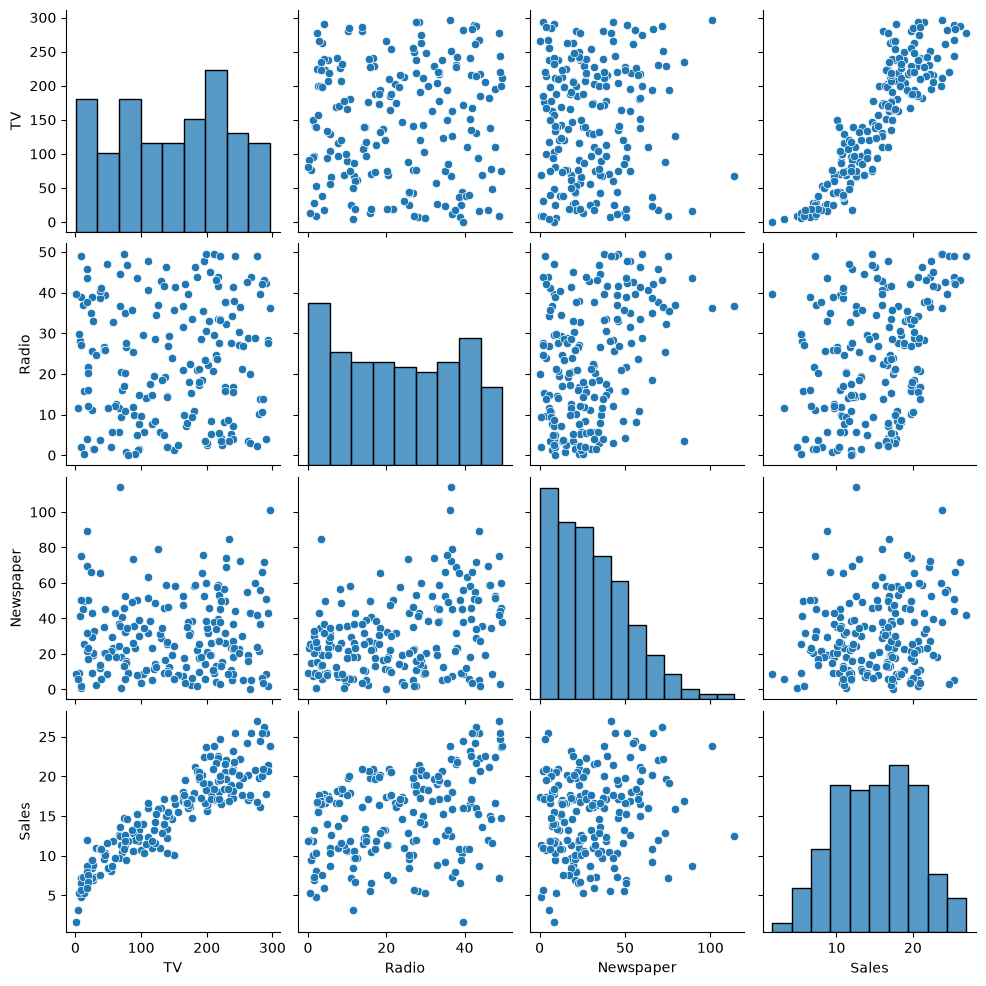

In [5]:
p = sns.pairplot(advert)

C:\Users\kwaku\anaconda3\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


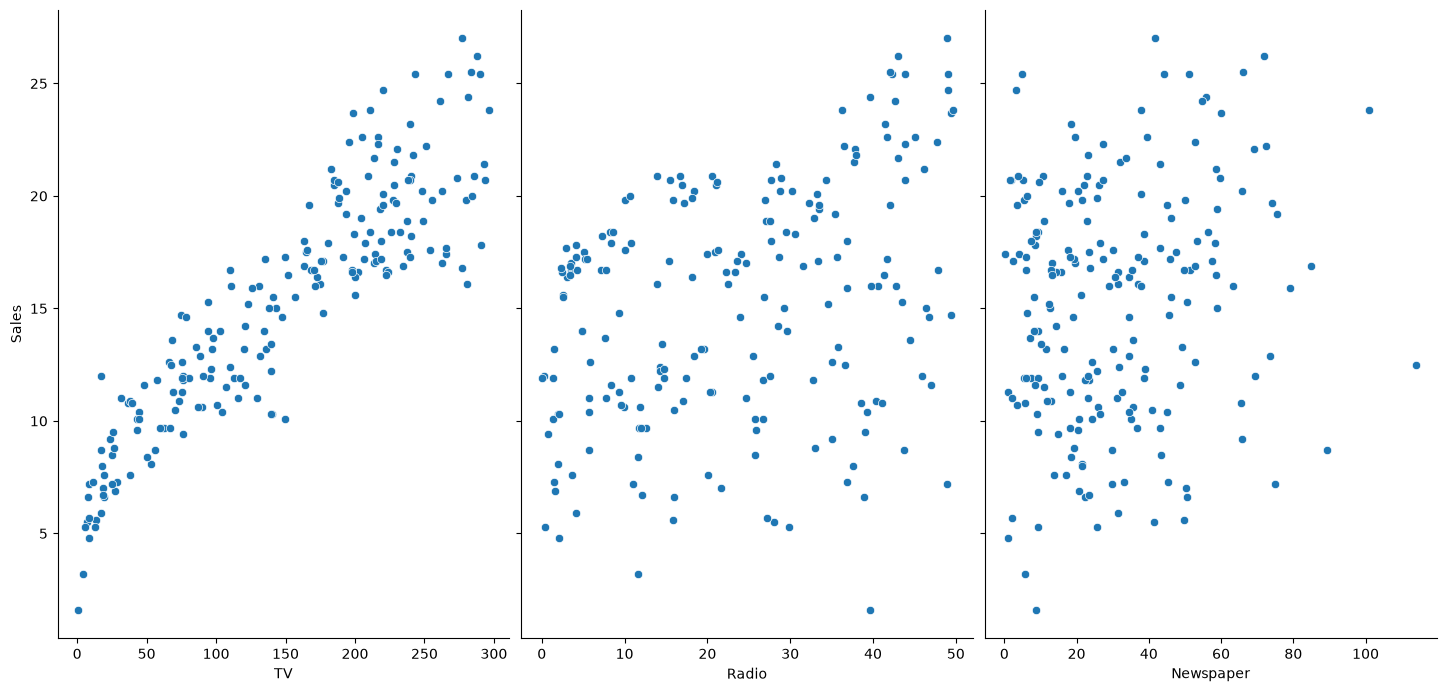

In [6]:
p = sns.pairplot(advert, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', size=7, aspect=0.7)

In [7]:
y = advert['Sales']
x = advert.drop(['Sales'], axis=1)

In [8]:
y.head()

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

In [9]:
x.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [10]:
sc = StandardScaler()
X = sc.fit_transform(x)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state = 0,test_size=0.25)

In [12]:
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_train)

In [13]:
print("R squared : ", r2_score(y_train, y_pred))

R squared :  0.9119295792061695


In [14]:
residuals = y_train.values - y_pred
mean_residuals = np.mean(residuals)
print(" Mean of residuals : ",mean_residuals)

 Mean of residuals :  -2.812564995717063e-15


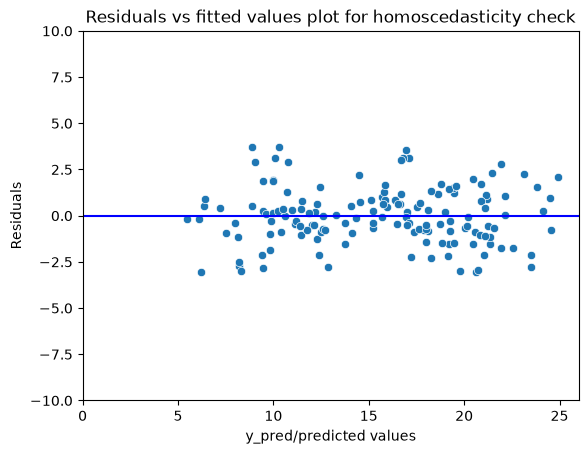

In [15]:
p = sns.scatterplot(x=y_pred,y=residuals)
plt.xlabel('y_pred/predicted values')
plt.ylabel('Residuals')
plt.ylim(-10,10)
plt.xlim(0,26)
p = sns.lineplot(x=[0,26],y=[0,0],color='blue')
p = plt.title('Residuals vs fitted values plot for homoscedasticity check')

### Testing for Homoskedasticity

#### goldfeldquandt

In [16]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(residuals, X_train)
lzip(name, test)

[('F statistic', np.float64(0.8860765671344406)),
 ('p-value', np.float64(0.6954020806468909))]

#### Bartlett's Test

In [17]:
from scipy.stats import bartlett
test = bartlett(residuals, X_train[:,0], X_train[:,1], X_train[:,2])
print(test)

BartlettResult(statistic=np.float64(50.006351738125844), pvalue=np.float64(7.964333619101184e-11))


C:\Users\kwaku\AppData\Local\Temp\ipykernel_4172\3040778317.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p = sns.distplot(residuals,kde=True)


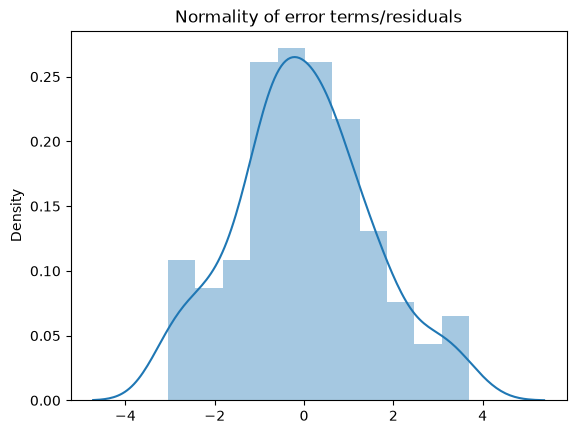

In [18]:
p = sns.distplot(residuals,kde=True)
p = plt.title('Normality of error terms/residuals')

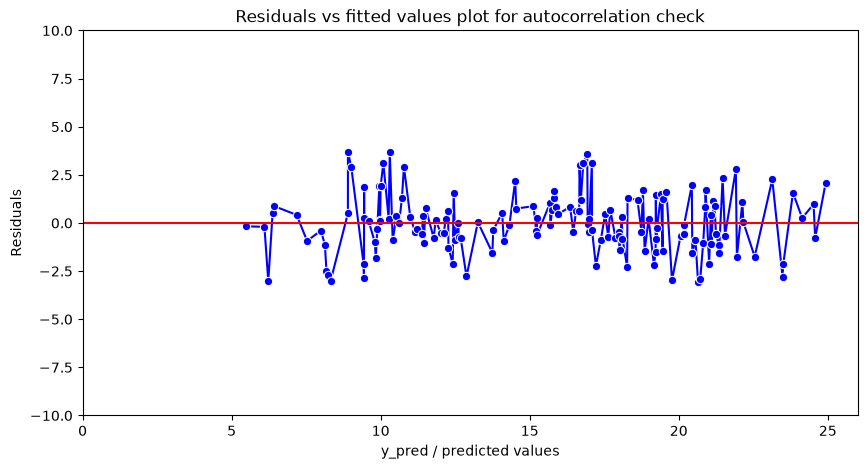

In [19]:
plt.figure(figsize=(10,5))
sns.lineplot(x=y_pred, y=residuals, marker='o', color='blue')
plt.xlabel('y_pred / predicted values')
plt.ylabel('Residuals')
plt.ylim(-10,10)
plt.xlim(0,26)
sns.lineplot(x=[0,26], y=[0,0], color='red')
plt.title('Residuals vs fitted values plot for autocorrelation check')
plt.show()

#### Ljund test for Autocorrelation

In [20]:
from statsmodels.stats import diagnostic as diag
min(diag.acorr_ljungbox(residuals, lags=40, return_df=True)['lb_pvalue'])

0.0936135915211556

#### Using ACF and PACF to check for Autocorrelation

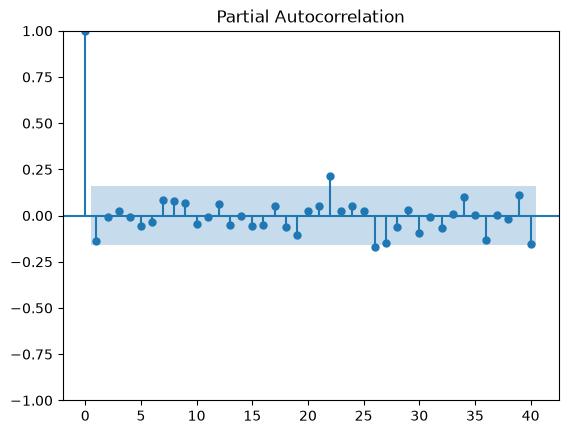

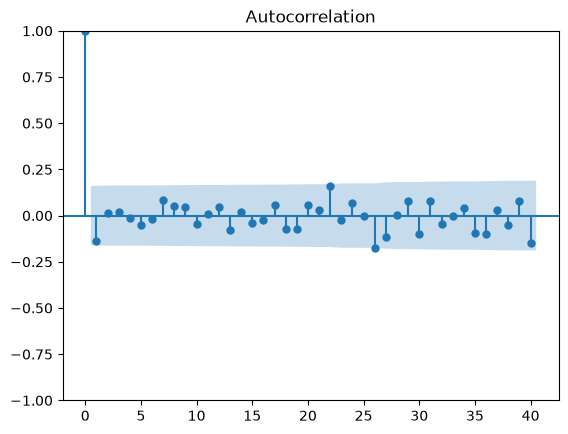

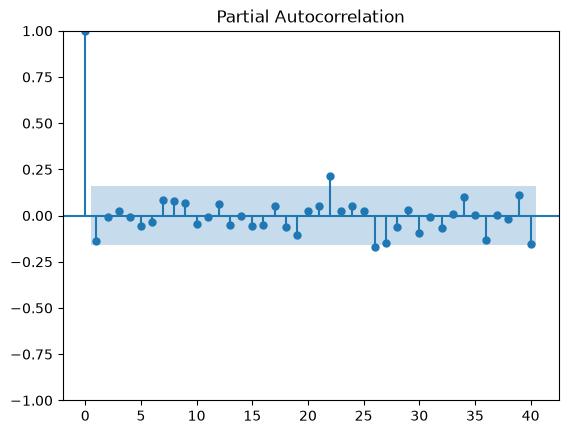

In [21]:
import statsmodels.api as sm
# autocorrelation
sm.graphics.tsa.plot_acf(residuals, lags=40)
# partial autocorrelation
sm.graphics.tsa.plot_pacf(residuals, lags=40)

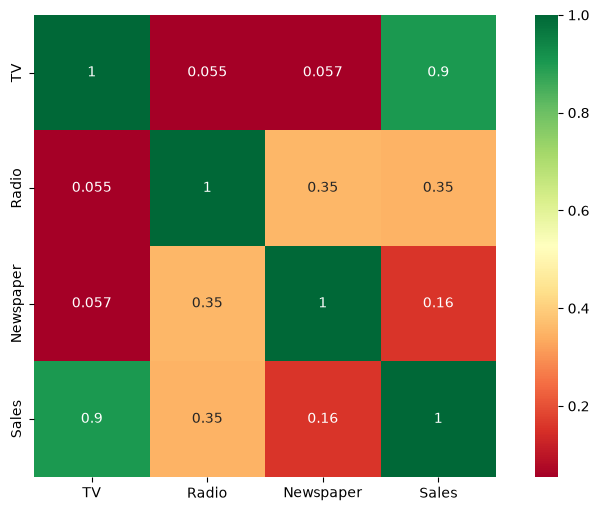

In [22]:
plt.figure(figsize=(10,6))
p=sns.heatmap(advert.corr(), annot = True, cmap = 'RdYlGn', square = True)